In [ ]:
## weeding_system_B_U ##
!pip install ultralytics
!unzip -q proje_dataset.zip -d dataset

replace dataset/agri_data/data/agri_0_1009.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import os
import shutil
import random

# 1. Kaynak ve Hedef Klasör Ayarları
source_path = "dataset/agri_data/data"
base_dir = "yolo_dataset"

# Klasör yapısını oluştur: images/train, images/val, labels/train, labels/val
sub_dirs = ["images/train", "images/val", "labels/train", "labels/val"]

for sub_dir in sub_dirs:
    os.makedirs(os.path.join(base_dir, sub_dir), exist_ok=True)

# 2. Dosyaları Listele
all_files = os.listdir(source_path)
# Sadece resim dosyalarını al (jpg, jpeg, png) - txt'leri ayır
images = [f for f in all_files if f.endswith(('.jpg', '.jpeg', '.png'))]
random.shuffle(images) # Rastgele karıştır ki eğitim dengeli olsun

# 3. Ayırma Oranı (%80 Eğitim, %20 Doğrulama)
split_ratio = 0.8
train_count = int(len(images) * split_ratio)

train_images = images[:train_count]
val_images = images[train_count:]

# 4. Dosyaları Taşıma Fonksiyonu
def move_files(file_list, type_name):
    for img_name in file_list:
        # Resim dosyasını taşı
        src_img = os.path.join(source_path, img_name)
        dst_img = os.path.join(base_dir, f"images/{type_name}", img_name)
        shutil.copy(src_img, dst_img)

        # Etiket dosyasını (.txt) bul ve taşı
        label_name = os.path.splitext(img_name)[0] + ".txt"
        src_label = os.path.join(source_path, label_name)
        dst_label = os.path.join(base_dir, f"labels/{type_name}", label_name)

        if os.path.exists(src_label):
            shutil.copy(src_label, dst_label)

print("Dosyalar ayrıştırılıyor ve taşınıyor...")
move_files(train_images, "train")
move_files(val_images, "val")
print(f"İşlem Tamam! Toplam {len(images)} resim işlendi.")
print(f"Eğitim: {len(train_images)}, Doğrulama: {len(val_images)}")

Dosyalar ayrıştırılıyor ve taşınıyor...
İşlem Tamam! Toplam 1300 resim işlendi.
Eğitim: 1040, Doğrulama: 260


In [ ]:
import yaml

class_names = ['crop', 'weed']

# YOLO için gerekli ayarlar
data_config = {
    'train': '/content/yolo_dataset/images/train', # Eğitim resimlerinin yeri
    'val':   '/content/yolo_dataset/images/val',   # Test resimlerinin yeri
    'nc':    len(class_names),                     # Sınıf sayısı (2)
    'names': class_names                           # ['crop', 'weed']
}

# data.yaml dosyasını oluşturup kaydediyoruz
with open('data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"✅ data.yaml başarıyla oluşturuldu!")
print(f"Sınıflar: {class_names}")

✅ data.yaml başarıyla oluşturuldu!
Sınıflar: ['crop', 'weed']


In [ ]:
## 5
!yolo task=detect mode=train model=yolov8n.pt data=data.yaml epochs=50 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, ker

Sonuçlar şu klasörden okunuyor: runs/detect/train


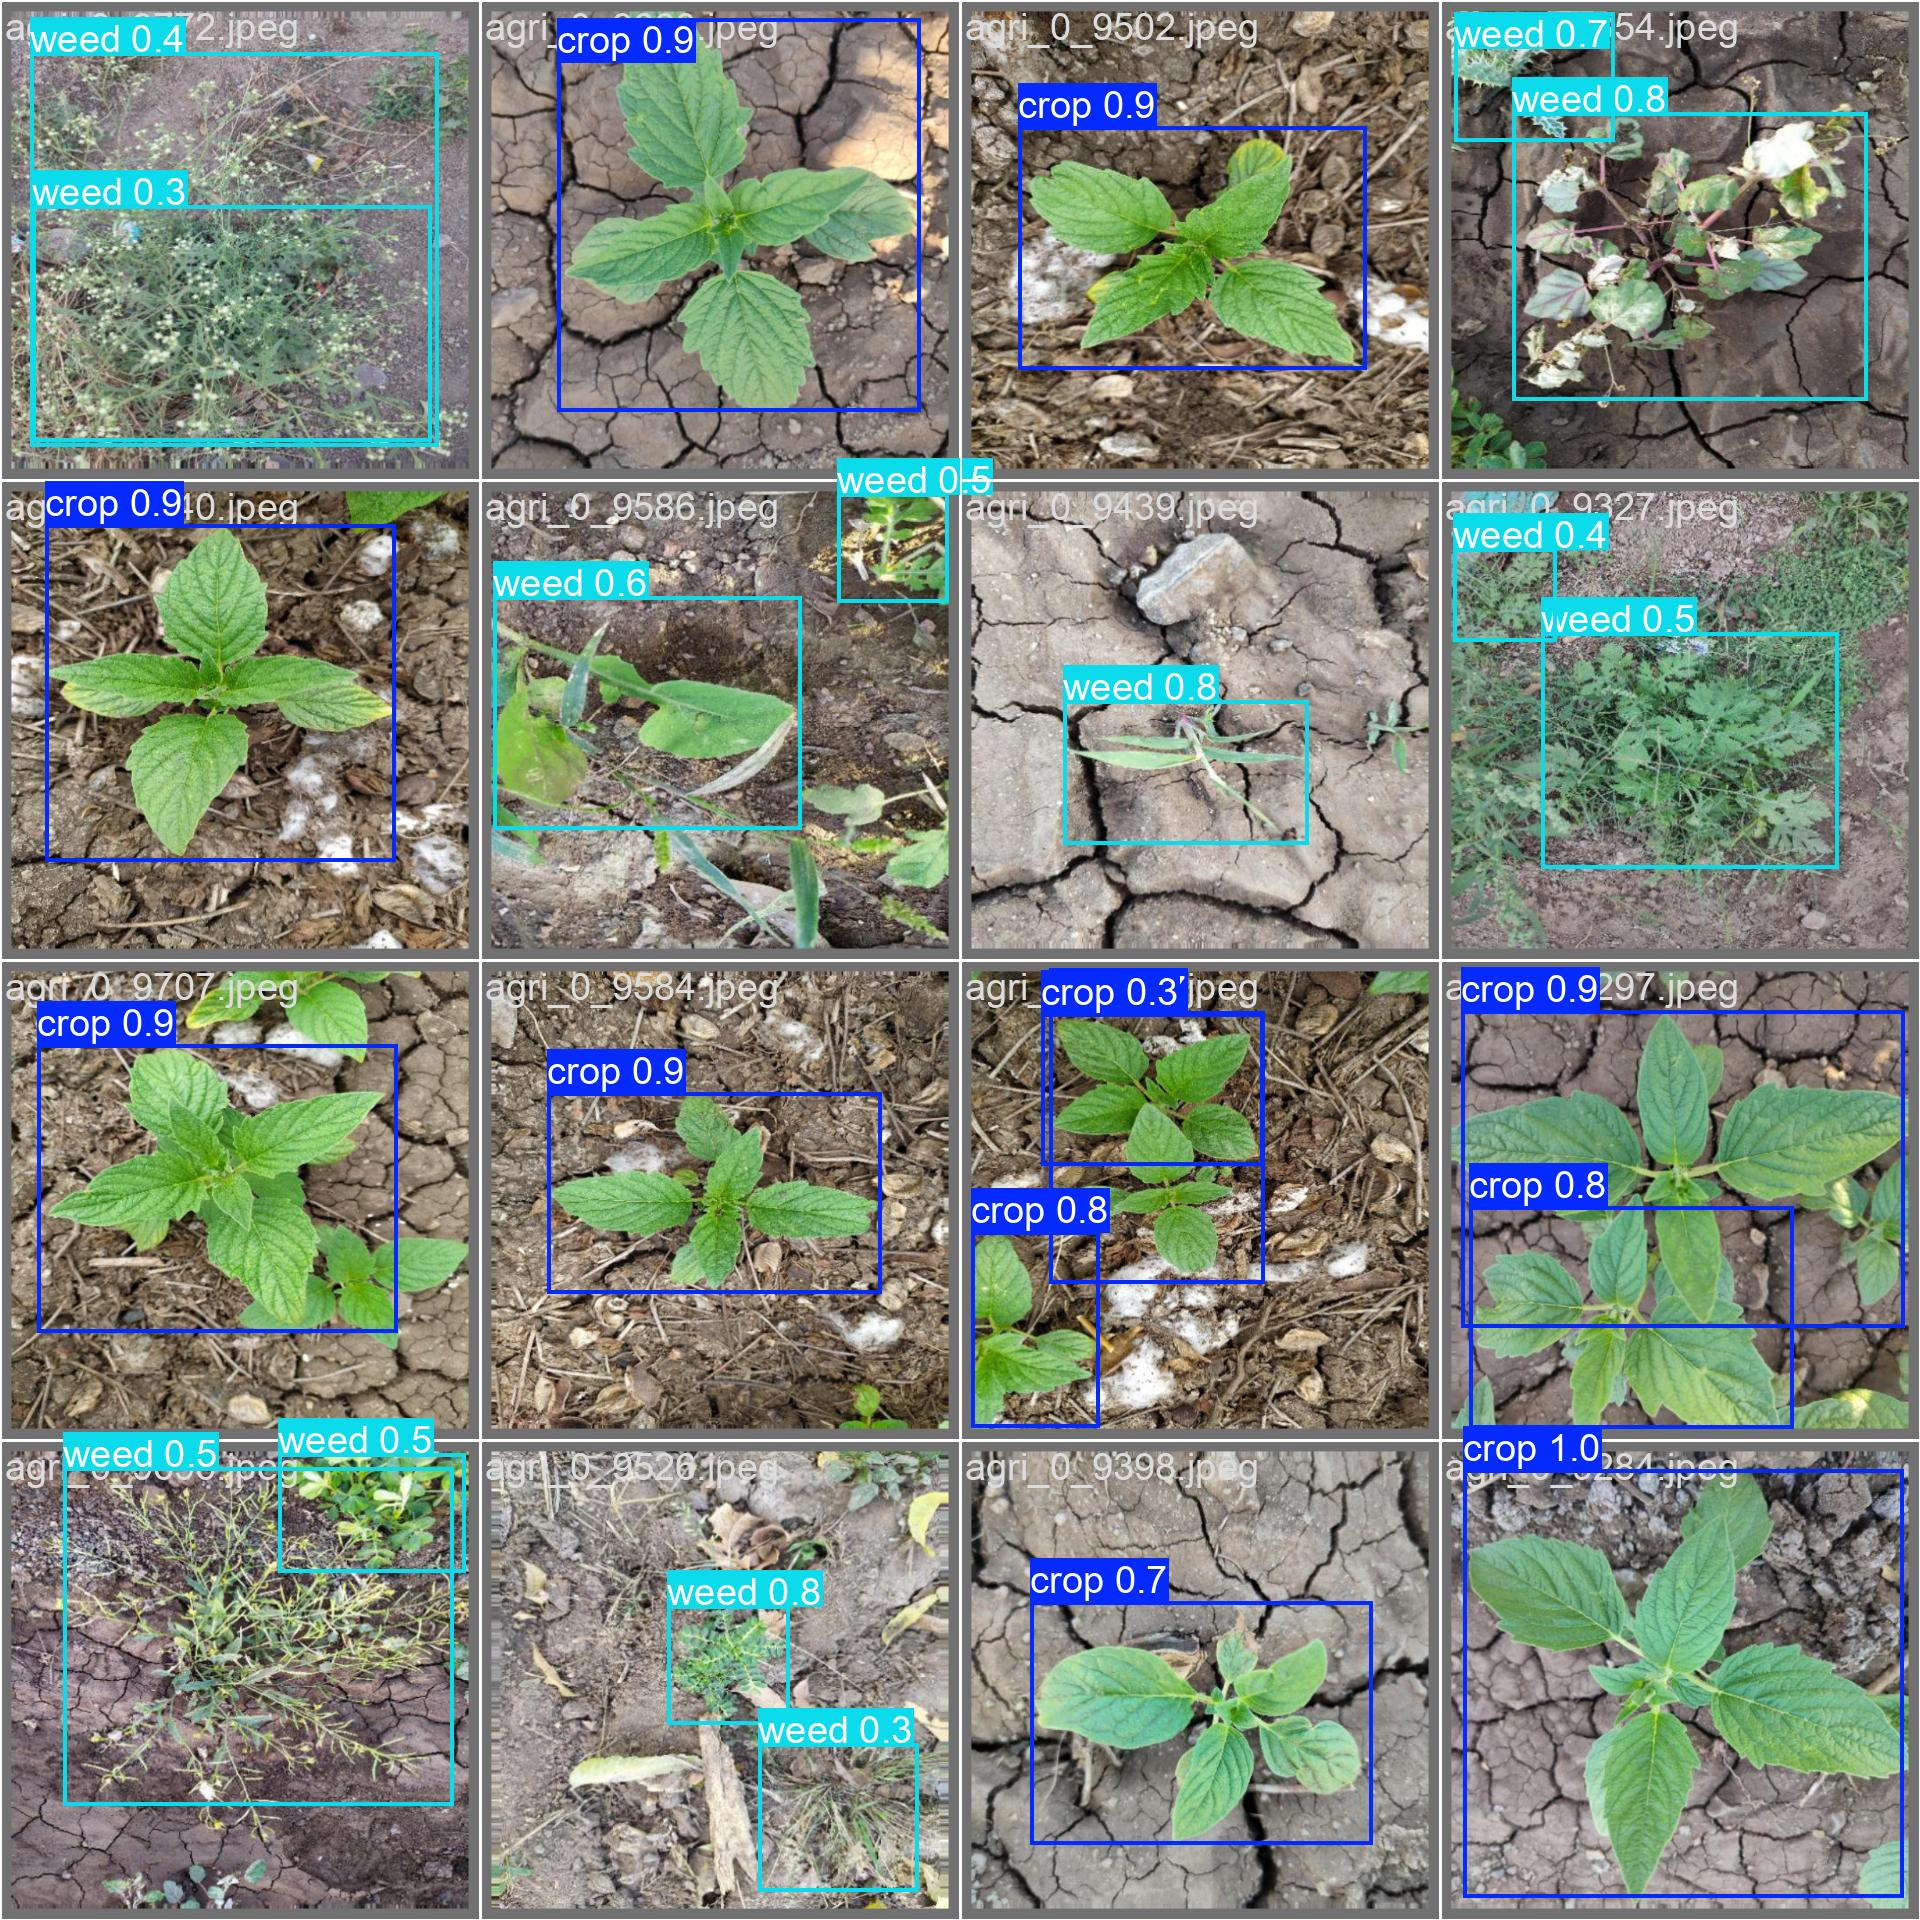

Gördüğün resimde kutucukların üzerinde 'weed' veya 'crop' yazmalı.


In [ ]:
from IPython.display import Image, display
import os

base_path = 'runs/detect'
folders = [os.path.join(base_path, f) for f in os.listdir(base_path) if 'train' in f]
latest_run = max(folders, key=os.path.getmtime)

print(f"Sonuçlar şu klasörden okunuyor: {latest_run}")

# Modelin tahminlerini gösteren örnek resim
val_pred_image = os.path.join(latest_run, 'val_batch0_pred.jpg')

if os.path.exists(val_pred_image):
    display(Image(filename=val_pred_image, width=800))
    print("Gördüğün resimde kutucukların üzerinde 'weed' veya 'crop' yazmalı.")
else:
    print("Örnek resim bulunamadı. Klasör yapısını kontrol etmemiz gerekebilir.")

In [ ]:
!zip -r model_dosyasi.zip runs/detect/train/weights/best.pt

  adding: runs/detect/train/weights/best.pt (deflated 9%)
